# Project Overview: Student Wellness & Academic Performance Analysis

### Objective
This project examines the multi-faceted relationship between lifestyle habits—specifically sleep, screen time, and physical activity—and student academic and mental health outcomes. 

### Methodology
* **Data Processing:** Developed a modular preprocessing pipeline to handle categorical and numerical features systematically.
* **Analysis:** Investigated correlations between daily routines (e.g., social media usage, exercise) and indicators like GPA, stress levels, and burnout.
* **Predictive Modeling:** Built a classification model to identify key behavioral predictors of student burnout.

### Key Findings
*(Add a summary here once you finish your analysis—e.g., "Results suggest that sleep duration is the most significant predictor of GPA, surpassing screen time metrics.")*

### 1. Environment Setup
Importing the necessary libraries for data manipulation, numerical computation, and visualization.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer

### 2. Data Loading
Loading the student wellness dataset and inspecting the first few rows to understand the structure and data types.

In [9]:
df = pd.read_csv("data/student_sleep_mental_health_2026.csv")
df.head()

,student_id,age,gender,education_level,avg_sleep_hours,screen_time_hours,social_media_hours,study_hours_per_day,exercise_hours_per_week,caffeine_drinks_per_day,stress_level,anxiety_score,gpa,uses_sleep_app,feels_burned_out
0,1,21,Non-binary,High School,8.0,4.9,3.7,5.0,4.8,1,7,7,3.35,False,True
1,2,19,Female,Undergraduate,7.3,7.7,5.3,2.8,4.2,1,8,8,2.81,True,True
2,3,19,Male,Undergraduate,6.1,7.3,3.6,3.6,5.8,1,8,10,3.01,True,True
3,4,16,Male,High School,6.2,7.4,4.0,0.4,2.0,4,9,10,2.76,False,True
4,5,20,Male,Graduate,5.6,12.5,8.3,2.6,6.2,3,10,10,2.67,False,True


### 3. Data Overview
Inspecting the DataFrame's metadata, including column data types and checking for null values, to ensure the dataset is ready for cleaning and analysis.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   str    
 3   education_level          3000 non-null   str    
 4   avg_sleep_hours          3000 non-null   float64
 5   screen_time_hours        3000 non-null   float64
 6   social_media_hours       3000 non-null   float64
 7   study_hours_per_day      3000 non-null   float64
 8   exercise_hours_per_week  3000 non-null   float64
 9   caffeine_drinks_per_day  3000 non-null   int64  
 10  stress_level             3000 non-null   int64  
 11  anxiety_score            3000 non-null   int64  
 12  gpa                      3000 non-null   float64
 13  uses_sleep_app           3000 non-null   bool   
 14  feels_burned_out         3000 non-n

In [11]:
# Drop the identifier column as it is not needed for behavioral modeling
df = df.drop(["student_id"], axis=1)

# Verify the transformation
df.head()

,age,gender,education_level,avg_sleep_hours,screen_time_hours,social_media_hours,study_hours_per_day,exercise_hours_per_week,caffeine_drinks_per_day,stress_level,anxiety_score,gpa,uses_sleep_app,feels_burned_out
0,21,Non-binary,High School,8.0,4.9,3.7,5.0,4.8,1,7,7,3.35,False,True
1,19,Female,Undergraduate,7.3,7.7,5.3,2.8,4.2,1,8,8,2.81,True,True
2,19,Male,Undergraduate,6.1,7.3,3.6,3.6,5.8,1,8,10,3.01,True,True
3,16,Male,High School,6.2,7.4,4.0,0.4,2.0,4,9,10,2.76,False,True
4,20,Male,Graduate,5.6,12.5,8.3,2.6,6.2,3,10,10,2.67,False,True


In [21]:
# separate features from target
X = df.drop(["feels_burned_out"],axis=1)
y = df.feels_burned_out


### 4. Target Variable Analysis
To understand the distribution of our target variable (feels_burned_out), we examine the class counts. This reveals a class imbalance that will influence our choice of evaluation metrics and modeling strategy.

In [22]:
y.value_counts()

feels_burned_out
True     2039
False     961
Name: count, dtype: int64

In [25]:
#separate categorical from numerical features
cat_cols = X.select_dtypes(include=['object', 'string', 'boolean']).columns.tolist()
num_cols = [col for col in X.columns if col not in cat_cols]
cat_cols, num_cols

(['gender', 'education_level', 'uses_sleep_app'],
 ['age',
  'avg_sleep_hours',
  'screen_time_hours',
  'social_media_hours',
  'study_hours_per_day',
  'exercise_hours_per_week',
  'caffeine_drinks_per_day',
  'stress_level',
  'anxiety_score',
  'gpa'])

### 5. Numerical Feature Analysis
We first examine the statistical properties of the numerical features and then visualize their distributions and correlation patterns to identify potential collinearity and skewness.

In [26]:
X.describe()

,age,avg_sleep_hours,screen_time_hours,social_media_hours,study_hours_per_day,exercise_hours_per_week,caffeine_drinks_per_day,stress_level,anxiety_score,gpa
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,19.445000,7.414067,6.494667,3.575033,3.235200,3.541900,1.778667,7.216667,7.152000,3.244487
std,2.924921,0.971279,2.165014,1.563631,1.405491,2.336889,1.341496,1.572433,1.994882,0.379404
min,14.000000,4.400000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.970000
25%,17.000000,6.800000,5.000000,2.500000,2.300000,1.800000,1.000000,6.000000,6.000000,2.980000
50%,19.000000,7.400000,6.500000,3.600000,3.200000,3.400000,2.000000,7.000000,7.000000,3.245000
75%,21.000000,8.100000,8.000000,4.600000,4.200000,5.100000,3.000000,8.000000,9.000000,3.510000
max,29.000000,10.900000,13.600000,9.000000,8.700000,11.300000,8.000000,10.000000,10.000000,4.000000


#### 5.2 Distributional Analysis
Visualizing the distribution of each numerical feature to identify skewness.

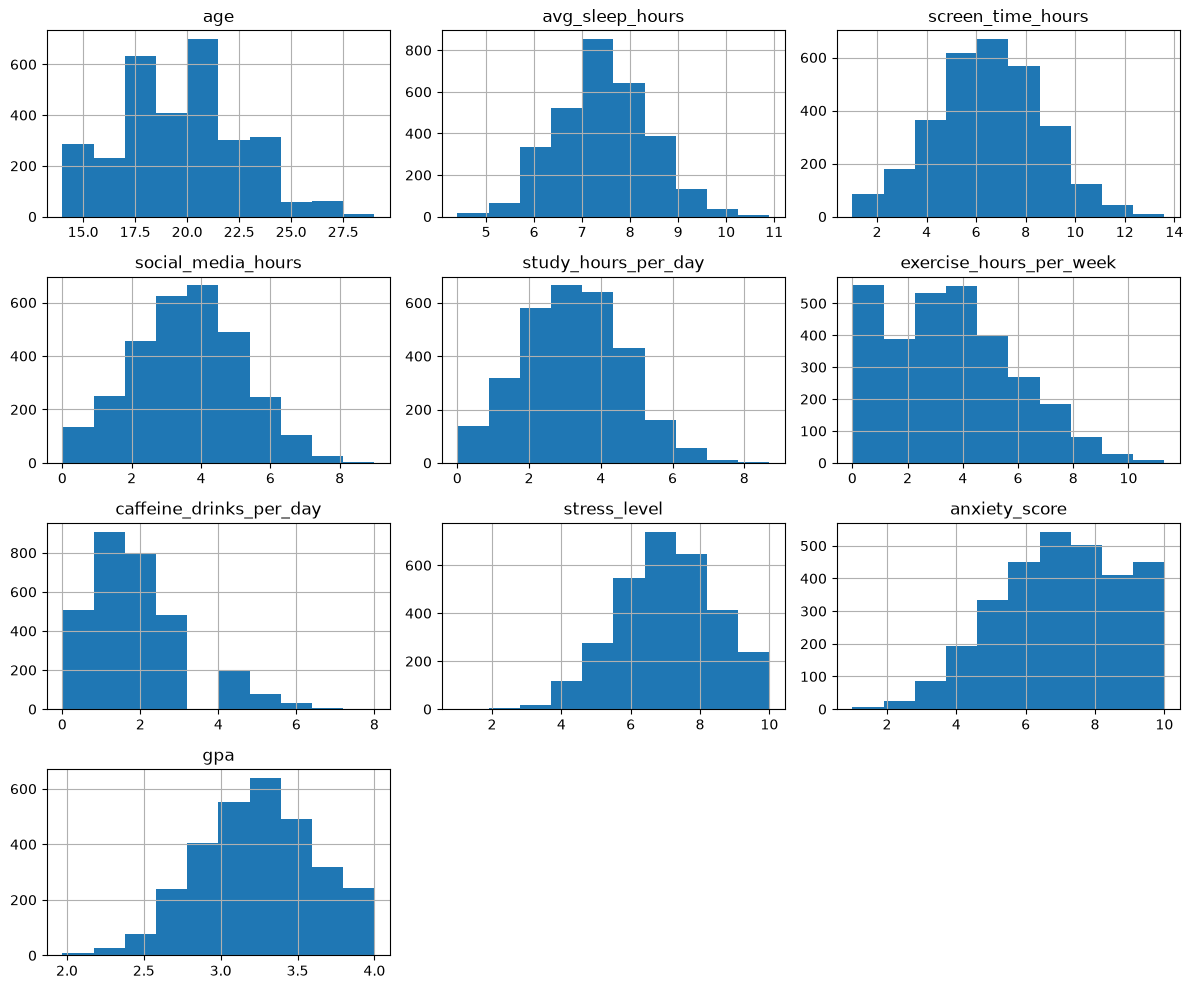

In [28]:
X[num_cols].hist(figsize=(12, 10))
plt.tight_layout()

### 5.3 Preprocessing Insights
After visualizing the numerical features, we observed that several variables (e.g., `caffeine_drinks_per_day`, `anxiety_score`) exhibit right-skewness. We tested log-transformations as a potential remedy; however, due to the discrete nature and narrow range of these features, the transformation introduced artificial gaps and distortions in the data distribution. 

Consequently, we have decided to bypass skew-correction transformations for these features. Since we are prioritizing tree-based models (Random Forest, XGBoost), which are invariant to monotonic transformations and splitting thresholds, this approach preserves the integrity of our original data while optimizing model performance.

# 5.4 Correlation analysis